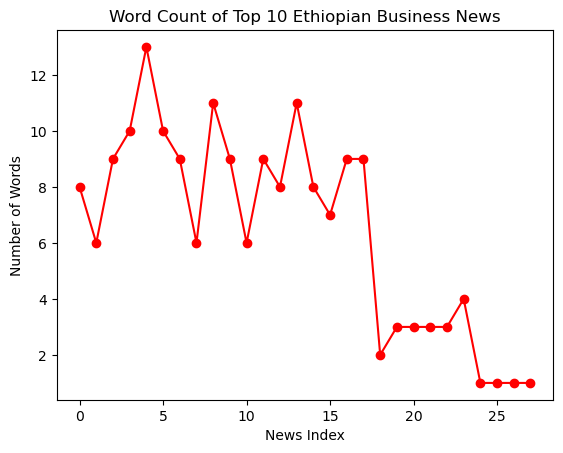

In [10]:
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt

import pandas as pd

url="https://newbusinessethiopia.com/"

# ድረ-ገጹ እንዳይከለክለን የምንጠቀመው መታወቂያ (User-Agent)
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response=requests.get(url,headers=headers)

soup=BeautifulSoup(response.text , "html.parser")

# print(soup)

All_Title=soup.find_all("h3")

titles_list=[]

for title in All_Title:
    titles_list.append(title.text.strip())
   

# print(titles_list[:10])
df=pd.DataFrame({
    "News_Title":titles_list
})
df["Word_Count"] = df["News_Title"].apply(lambda x: len(x.split()))
# print(df)
top_10_df=df.head(100)
plt.plot(top_10_df.index, top_10_df["Word_Count"], color="red", marker="o", linestyle="-")
# ርዕስ እና መግለጫዎች
plt.title("Word Count of Top 10 Ethiopian Business News")
plt.xlabel("News Index")
plt.ylabel("Number of Words")
# ግራፉን ማሳየት
plt.show()
